In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Create dataset

In [16]:
data = {
    "Study_Hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Marks": [35, 42, 48, 55, 61, 68, 74, 81, 87, 94]
}


In [17]:
df = pd.DataFrame(data)

## Understand dataset

In [18]:
print(df.head())

   Study_Hours  Marks
0            1     35
1            2     42
2            3     48
3            4     55
4            5     61


In [19]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Study_Hours  10 non-null     int64
 1   Marks        10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes
None


In [20]:
print(df.shape)

(10, 2)


In [21]:
print(df.describe())

       Study_Hours      Marks
count     10.00000  10.000000
mean       5.50000  64.500000
std        3.02765  19.727308
min        1.00000  35.000000
25%        3.25000  49.750000
50%        5.50000  64.500000
75%        7.75000  79.250000
max       10.00000  94.000000


## Visualization

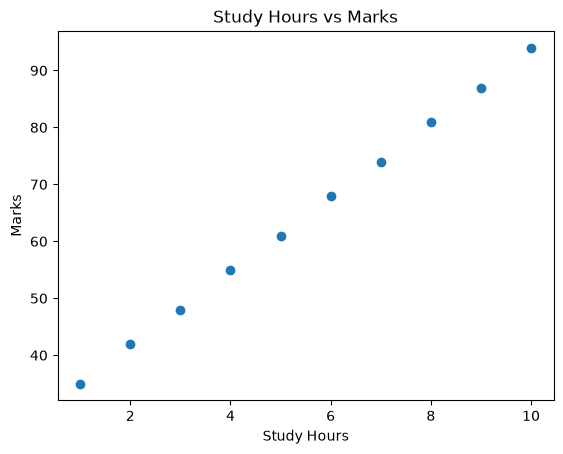

In [22]:
plt.scatter(df["Study_Hours"], df["Marks"])

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study Hours vs Marks")

plt.show()

## Select X and y

In [23]:
X = df[["Study_Hours"]]
y = df["Marks"]

## Train-test split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Create model

In [25]:
model = LinearRegression()

## Train model

In [26]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[6.55]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Study_Hours']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,28.47
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


## Coefficient and intercept

In [27]:
print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)


Coefficient: [6.55172414]
Intercept: 28.46551724137931


## Make Prediction

In [28]:
y_pred = model.predict(X_test)

## Actual Value vs Predicted Value

In [29]:
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(result)

   Actual  Predicted
0      87  87.431034
1      42  41.568966


## Model Evaluation

In [30]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)


print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)


MAE : 0.4310344827586192
MSE : 0.1857907253269904
RMSE: 0.4310344827586192
R²  : 0.9996330059746628


## Drawing Regression line

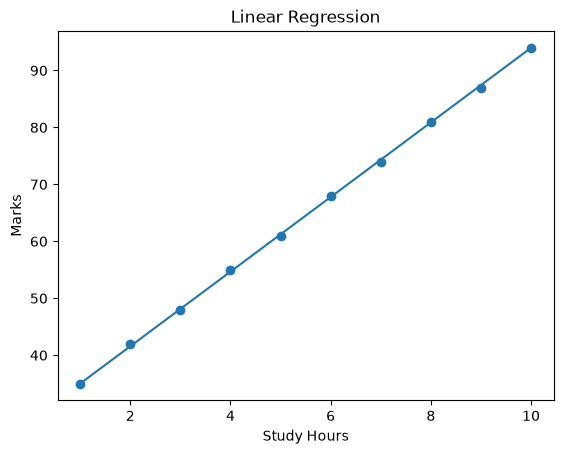

In [31]:
plt.scatter(X, y)

plt.plot(X, model.predict(X))

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Linear Regression")

plt.show()

## Making New prediction

In [32]:
new_data = [[7.5]]

prediction = model.predict(new_data)

print("Predicted Marks:", prediction[0])

Predicted Marks: 77.60344827586206
